# Reintegration Readiness Predictor
**Eban-Haven Platform — Resident Case Management Pipeline**

| | |
|---|---|
| **Paradigm** | Predictive (binary classification) |
| **Business Question** | Which residents look most likely to be ready for reintegration? |
| **Primary Metrics** | ROC-AUC, F0.5, Precision, Recall |
| **Validation Strategy** | Held-out test split + Stratified 5-fold CV |
| **Deployment Artifact** | `ml-pipelines/reintegration_model.joblib` |


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.inspection import permutation_importance

from retrain_reintegration_model import (
    FEATURE_COLS,
    NUM_COLS,
    OBS_HORIZON_DAYS,
    fit_final_model,
    load_dataset_from_environment,
    evaluate_models,
)

sns.set_theme(style="whitegrid")


## 1. Problem Framing

This is an operational **predictive** pipeline. Case managers need a ranked signal that helps them decide who may be approaching reintegration readiness; they do not primarily need a causal estimate of why reintegration happens.

### Updated target definition
The original `Completed vs everything else` framing mixed together residents who were simply early in care with residents who had genuinely stalled. The improved version uses a **mature cohort**:
- **Positive (1):** `reintegration_status == Completed`
- **Negative (0):** resident has **at least 540 observed days in programme** and still has not completed

That target is still imperfect, but it is closer to the real decision problem than labeling every active resident as “not ready.”


## 2. Data Acquisition, Preparation & Exploration

This notebook uses Azure PostgreSQL as its primary data source when `HAVEN_DB_CONN` is available. The committed CSV snapshots in `backend/EbanHaven.Api/Data/lighthouse/` exist only as an offline fallback for reproducibility when the live database is unavailable.

The preparation logic mirrors the deployed API feature assembly: resident demographics, process recordings, education, health, incidents, and intervention plans are aggregated into a single row per resident. Keeping that feature contract aligned is critical because the web app sends these fields directly to the model endpoint.


In [2]:
df_model, data_source = load_dataset_from_environment(prompt_if_missing=False)
print(f"Data source: {data_source}")
print(f"Rows after mature-cohort filter: {len(df_model)}")
print(f"Positive rate: {df_model['target'].mean():.1%}")
print(df_model[FEATURE_COLS + ['target']].isna().mean().sort_values(ascending=False).head(10))
df_model.head(3)


/Users/lukecarr/Desktop/MassiveFolder/ml-pipelines/retrain_reintegration_model.py:253: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  residents = pd.read_sql_query(


/Users/lukecarr/Desktop/MassiveFolder/ml-pipelines/retrain_reintegration_model.py:257: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  safehouses = pd.read_sql_query("SELECT safehouse_id, safehouse_code FROM safehouses", conn)
/Users/lukecarr/Desktop/MassiveFolder/ml-pipelines/retrain_reintegration_model.py:258: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  process_recordings = pd.read_sql_query("SELECT resident_id, progress_noted, concerns_flagged FROM process_recordings", conn)


/Users/lukecarr/Desktop/MassiveFolder/ml-pipelines/retrain_reintegration_model.py:259: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  education_records = pd.read_sql_query("SELECT resident_id, progress_percent FROM education_records", conn)
/Users/lukecarr/Desktop/MassiveFolder/ml-pipelines/retrain_reintegration_model.py:260: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  health_records = pd.read_sql_query("SELECT resident_id, general_health_score FROM health_wellbeing_records", conn)


/Users/lukecarr/Desktop/MassiveFolder/ml-pipelines/retrain_reintegration_model.py:261: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  incident_reports = pd.read_sql_query("SELECT resident_id, severity FROM incident_reports", conn)
/Users/lukecarr/Desktop/MassiveFolder/ml-pipelines/retrain_reintegration_model.py:262: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  intervention_plans = pd.read_sql_query("SELECT resident_id, status FROM intervention_plans", conn)


Data source: azure_postgresql
Rows after mature-cohort filter: 48
Positive rate: 39.6%
safehouse_id                0.0
avg_progress_percent        0.0
active_plan_count           0.0
pct_plans_achieved          0.0
total_plans                 0.0
num_severe_incidents        0.0
total_incidents             0.0
num_health_records          0.0
pct_psych_checkup_done      0.0
avg_general_health_score    0.0
dtype: float64


,resident_id,reintegration_status,target,safehouse_id,age_at_entry,days_in_program,referral_source,current_risk_level,reintegration_type,case_status,...,latest_attendance_rate,avg_progress_percent,avg_general_health_score,pct_psych_checkup_done,num_health_records,total_incidents,num_severe_incidents,total_plans,pct_plans_achieved,active_plan_count
0,26,Not Started,0,SH03,20,989.154885,Unknown,Low,Foster Care,Closed,...,0.0,82.175000,3.233750,0.0,8.0,3.0,1.0,3.0,0.0,3.0
1,52,Completed,1,SH02,16,790.154885,Unknown,Low,Foster Care,Closed,...,0.0,31.842857,3.025714,0.0,7.0,3.0,2.0,3.0,0.0,3.0
2,53,Completed,1,SH06,14,914.154885,Unknown,Low,Adoption (Domestic),Active,...,0.0,94.850000,3.370833,0.0,12.0,2.0,1.0,3.0,0.0,3.0


target                      1.000000
age_at_entry                0.276312
active_plan_count           0.209338
num_severe_incidents        0.104114
days_in_program             0.076865
pct_concerns_flagged        0.067067
total_sessions              0.060489
num_health_records          0.020310
pct_progress_noted         -0.006237
total_incidents            -0.008883
avg_progress_percent       -0.013070
pct_plans_achieved         -0.210223
avg_general_health_score   -0.213655
latest_attendance_rate           NaN
pct_psych_checkup_done           NaN
total_plans                      NaN
Name: target, dtype: float64

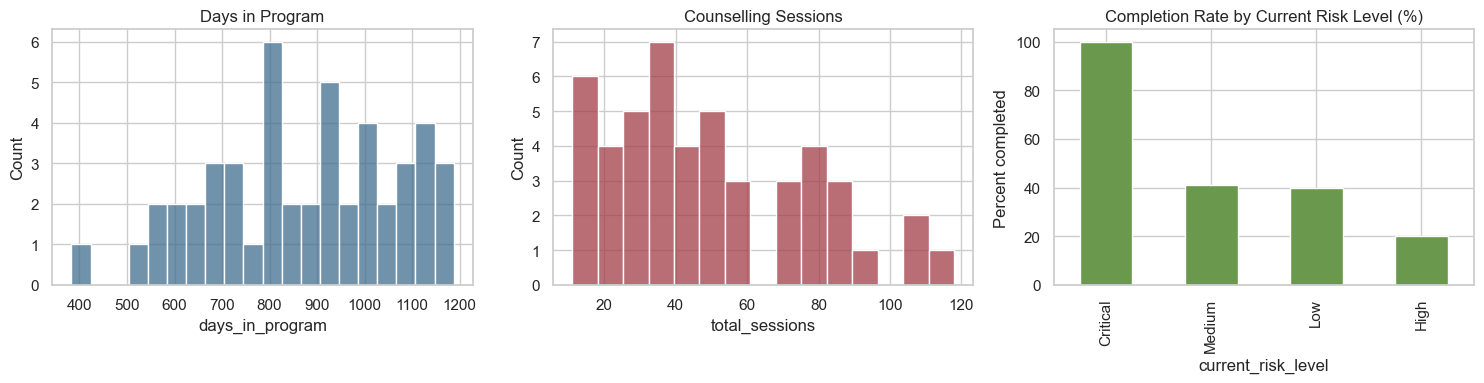

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df_model['days_in_program'], bins=20, ax=axes[0], color='#406E8E')
axes[0].set_title('Days in Program')

sns.histplot(df_model['total_sessions'], bins=15, ax=axes[1], color='#A23E48')
axes[1].set_title('Counselling Sessions')

(df_model.groupby('current_risk_level')['target']
 .mean()
 .sort_values(ascending=False)
 .mul(100)
 .plot(kind='bar', ax=axes[2], color='#6A994E'))
axes[2].set_title('Completion Rate by Current Risk Level (%)')
axes[2].set_ylabel('Percent completed')
plt.tight_layout()

df_model[NUM_COLS + ['target']].corr(numeric_only=True)['target'].sort_values(ascending=False)


## 3. Modeling & Feature Selection

This remains a textbook **predictive** workflow:
- preprocessing embedded in a reusable scikit-learn pipeline
- multiple candidate models compared
- out-of-sample selection based on held-out performance, not coefficient interpretability
- correlated predictors are allowed if they help generalization

The deployed feature contract currently includes the richer resident fields `current_risk_level`, `reintegration_type`, `case_status`, and `active_plan_count` so the notebook and the app stay aligned.


In [4]:
X = df_model[FEATURE_COLS].copy()
y = df_model['target'].astype(int).copy()

best_name, results = evaluate_models(X, y)
results_table = pd.DataFrame(results).T.sort_values(['f0_5_test', 'roc_auc_test'], ascending=False)
results_table


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
   

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
   

,best_threshold,roc_auc_test,f0_5_test,precision_test,recall_test,cv_roc_auc_mean,cv_f1_mean
gbm,0.0616,0.400000,0.487805,0.444444,0.8,0.330000,0.100000
rf,0.1886,0.342857,0.471698,0.416667,1.0,0.301111,0.194444
logreg,0.6575,0.342857,0.000000,0.000000,0.0,0.432778,0.307778


## 4. Evaluation & Interpretation

The most important business tradeoff here is between:
- **False positives:** predicting a resident is ready when she is not, which could support a premature transition
- **False negatives:** keeping a ready resident in care longer than necessary, which can slow reintegration momentum and reduce bed availability

Because the organization is more risk-sensitive to premature reintegration, the workflow uses **F0.5** as a selection-friendly metric in addition to ROC-AUC.


Selected model: gbm
              precision    recall  f1-score   support

           0      0.667     0.286     0.400         7
           1      0.444     0.800     0.571         5

    accuracy                          0.500        12
   macro avg      0.556     0.543     0.486        12
weighted avg      0.574     0.500     0.471        12

{'roc_auc_test': 0.4, 'f0_5_test': 0.4878048780487805, 'precision_test': 0.4444444444444444, 'recall_test': 0.8}


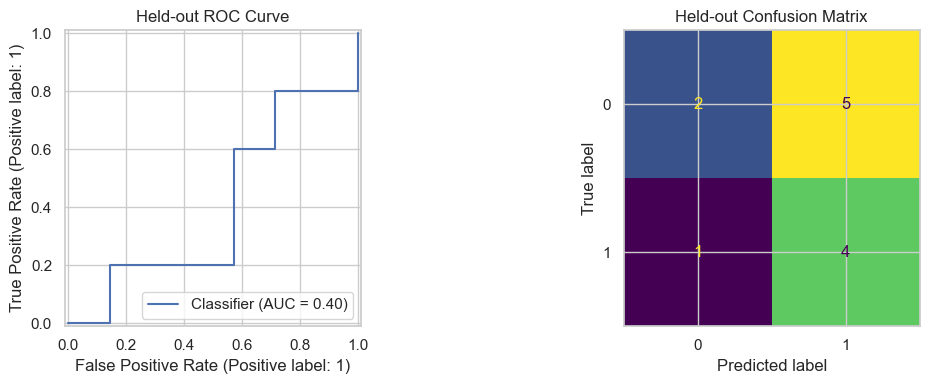

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import fbeta_score, precision_score, recall_score, roc_auc_score, classification_report, ConfusionMatrixDisplay, RocCurveDisplay

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
best_threshold = float(results[best_name]['best_threshold'])
best_model = fit_final_model(best_name, X_train, y_train)

test_probs = best_model.predict_proba(X_test)[:, 1]
test_preds = (test_probs >= best_threshold).astype(int)

print(f"Selected model: {best_name}")
print(classification_report(y_test, test_preds, digits=3))
print({
    'roc_auc_test': roc_auc_score(y_test, test_probs),
    'f0_5_test': fbeta_score(y_test, test_preds, beta=0.5, zero_division=0),
    'precision_test': precision_score(y_test, test_preds, zero_division=0),
    'recall_test': recall_score(y_test, test_preds, zero_division=0),
})

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
RocCurveDisplay.from_predictions(y_test, test_probs, ax=axes[0])
axes[0].set_title('Held-out ROC Curve')
ConfusionMatrixDisplay.from_predictions(y_test, test_preds, ax=axes[1], colorbar=False)
axes[1].set_title('Held-out Confusion Matrix')
plt.tight_layout()


## 5. Causal and Relationship Analysis

This is still a **predictive** model, so feature importance does **not** justify causal claims. The point of this section is to understand what structure the model is using, while being explicit that counselor notes, intervention plans, and incident counts may also reflect institutional processes or staff beliefs rather than clean causal drivers.


,feature,importance
16,num_severe_incidents,0.037714
5,reintegration_type,0.018286
10,latest_attendance_rate,0.000000
9,pct_concerns_flagged,0.000000
18,pct_plans_achieved,0.000000
17,total_plans,0.000000
13,pct_psych_checkup_done,0.000000
19,active_plan_count,0.000000
6,case_status,0.000000
4,current_risk_level,0.000000


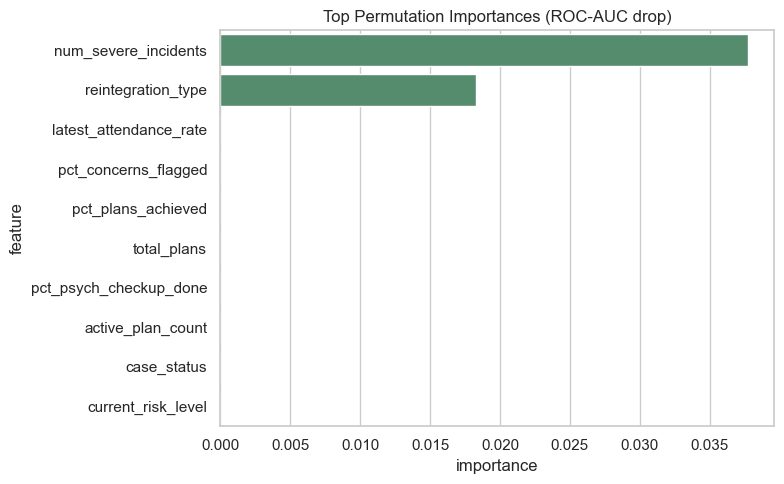

In [6]:
perm = permutation_importance(best_model, X_test, y_test, n_repeats=25, random_state=42, scoring='roc_auc')
importance_df = (
    pd.DataFrame({'feature': FEATURE_COLS, 'importance': perm.importances_mean})
    .sort_values('importance', ascending=False)
)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df.head(10), y='feature', x='importance', color='#4C956C')
plt.title('Top Permutation Importances (ROC-AUC drop)')
plt.tight_layout()
importance_df.head(10)


## 6. Deployment Notes

This model is integrated into the resident workflow through:
- [ReintegrationReadinessController.cs](/Users/lukecarr/Desktop/MassiveFolder/backend/EbanHaven.Api/Controllers/ReintegrationReadinessController.cs)
- [app.py](/Users/lukecarr/Desktop/MassiveFolder/ml-pipelines/app.py)
- [ReintegrationReadiness.tsx](/Users/lukecarr/Desktop/MassiveFolder/frontend/src/components/ml/ReintegrationReadiness.tsx)
- [ReintegrationReadinessPage.tsx](/Users/lukecarr/Desktop/MassiveFolder/frontend/src/pages/admin/databases/ReintegrationReadinessPage.tsx)

That means the notebook, artifact, API payload, and frontend dashboard all use the same feature contract.


In [7]:
from retrain_reintegration_model import MODEL_PATH, METADATA_PATH
import joblib

final_model = fit_final_model(best_name, X, y)
benchmark_medians = (
    df_model.loc[df_model['target'] == 1, [c for c in FEATURE_COLS if c in df_model.columns and c not in {'safehouse_id', 'referral_source', 'current_risk_level', 'reintegration_type', 'case_status'}]]
    .median(numeric_only=True)
    .fillna(0.0)
    .to_dict()
)
metadata = {
    'model_name': f'reintegration_readiness_{best_name}',
    'model_version': '4.0.0',
    'target': f'reintegration_status == Completed among residents with >= {OBS_HORIZON_DAYS} observed days or completed exit',
    'labeling_strategy': 'Mature-cohort readiness model using enriched resident aggregates',
    'feature_columns': FEATURE_COLS,
    'best_threshold': round(float(best_threshold), 4),
    'roc_auc_test': round(float(roc_auc_score(y_test, test_probs)), 4),
    'f0_5_test': round(float(fbeta_score(y_test, test_preds, beta=0.5, zero_division=0)), 4),
    'precision_test': round(float(precision_score(y_test, test_preds, zero_division=0)), 4),
    'recall_test': round(float(recall_score(y_test, test_preds, zero_division=0)), 4),
    'cv_roc_auc_mean': round(float(results[best_name]['cv_roc_auc_mean']), 4),
    'cv_f1_mean': round(float(results[best_name]['cv_f1_mean']), 4),
    'n_training_samples': int(len(df_model)),
    'n_positive_total': int(y.sum()),
    'n_negative_total': int((1 - y).sum()),
    'observation_horizon_days': OBS_HORIZON_DAYS,
    'benchmark_medians': {k: round(float(v), 4) for k, v in benchmark_medians.items()},
    'data_source': data_source,
    'primary_data_source': 'azure_postgresql',
    'fallback_data_source': 'csv_snapshot',
    'data_source_role': 'primary' if data_source == 'azure_postgresql' else 'fallback_only',
}
joblib.dump(final_model, MODEL_PATH)
METADATA_PATH.write_text(json.dumps(metadata, indent=2))
metadata


{'model_name': 'reintegration_readiness_gbm',
 'model_version': '4.0.0',
 'target': 'reintegration_status == Completed among residents with >= 540 observed days or completed exit',
 'labeling_strategy': 'Mature-cohort readiness model using enriched resident aggregates',
 'feature_columns': ['safehouse_id',
  'age_at_entry',
  'days_in_program',
  'referral_source',
  'current_risk_level',
  'reintegration_type',
  'case_status',
  'total_sessions',
  'pct_progress_noted',
  'pct_concerns_flagged',
  'latest_attendance_rate',
  'avg_progress_percent',
  'avg_general_health_score',
  'pct_psych_checkup_done',
  'num_health_records',
  'total_incidents',
  'num_severe_incidents',
  'total_plans',
  'pct_plans_achieved',
  'active_plan_count'],
 'best_threshold': 0.0616,
 'roc_auc_test': 0.4,
 'f0_5_test': 0.4878,
 'precision_test': 0.4444,
 'recall_test': 0.8,
 'cv_roc_auc_mean': 0.33,
 'cv_f1_mean': 0.1,
 'n_training_samples': 48,
 'n_positive_total': 19,
 'n_negative_total': 29,
 'obser